# Núcleo 1 — Serie histórica de coparticipación (2003-2025)

Este notebook analiza la evolución de la coparticipación federal recibida por las
provincias argentinas, en pesos corrientes y en pesos constantes (deflactados por
IPC), con foco en la provincia de Córdoba.

**Alcance**: 2003-2025 (ampliado desde el rango original 2016-2025 al incorporar una
fuente de IPC confiable para 2003-2015: Fundación Norte y Sur / Orlando Ferreres). No
llega a 1990 porque no existe una fuente de **montos nominales** de coparticipación
para 1990-2002 — el detalle completo de este empalme y de esa limitación está en
`docs/methodology.md`, secciones "Alcance temporal: 2003-2025" y "Empalme del IPC
2003-2015".

**Qué es "coparticipación" acá**: la suma del concepto Ley 23.548 (coparticipación
federal de impuestos, reportado como bruto o neto de Financiamiento Educativo Ley
26.075 según el año) más la compensación del Consenso Fiscal (Ley 27.429, desde 2018).
Ver `docs/methodology.md` para la definición completa y por qué se excluyen otros
regímenes de Recursos de Origen Nacional (IVA, Ganancias, Bienes Personales, etc.).

**Fuente de los datos procesados**: `data/processed/coparticipacion_real.csv`,
generado por `scripts/process_coparticipacion.py`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Paleta y estilo (validados con el validador de la skill de dataviz del proyecto:
# 4 colores categóricos en orden fijo, pasan los chequeos de daltonismo para líneas).
COLOR_CORDOBA = "#2a78d6"      # slot 1 - azul
COLOR_BUENOS_AIRES = "#eb6834" # slot 2 - naranja
COLOR_SANTA_FE = "#1baf7a"     # slot 3 - aqua
COLOR_MENDOZA = "#eda100"      # slot 4 - amarillo

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

BASE_DIR = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
FIGURES_DIR = BASE_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE_DIR / "data" / "processed" / "coparticipacion_real.csv")
df.head()


,provincia,anio,monto_nominal,ipc_promedio_anual,monto_real_base2016
0,Buenos Aires,2003,2787.1198,8.396631,33193.308951
1,Buenos Aires,2004,4317.3949,8.767403,49243.714747
2,Buenos Aires,2005,5400.0342,9.612726,56175.885844
3,Buenos Aires,2006,6474.5877,10.660302,60735.497648
4,Buenos Aires,2007,8503.3083,12.185142,69784.234690


## 1. Verificación rápida de los datos

552 filas esperadas: 24 jurisdicciones (23 provincias + CABA) × 23 años (2003-2025).
`monto_nominal` está en millones de pesos corrientes; `monto_real_base2016` está en
millones de pesos constantes, base promedio 2016 = 100.


In [2]:
print(f"Filas: {len(df)}  |  Provincias: {df['provincia'].nunique()}  |  Años: {df['anio'].min()}-{df['anio'].max()}")
assert len(df) == 552, "Se esperaban 552 filas (24 jurisdicciones x 23 años)"
df.describe()


Filas: 552  |  Provincias: 24  |  Años: 2003-2025


,anio,monto_nominal,ipc_promedio_anual,monto_real_base2016
count,552.000000,5.520000e+02,552.000000,552.000000
mean,2014.000000,2.015736e+05,863.364558,17412.138042
std,6.639266,7.210380e+05,2171.333299,17892.558618
min,2003.000000,1.605410e+02,8.396631,1911.969128
25%,2008.000000,1.639511e+03,14.979653,7850.774350
50%,2014.000000,7.216549e+03,56.976539,12331.096376
75%,2020.000000,5.740059e+04,330.541683,19824.263155
max,2025.000000,1.023990e+07,8966.166533,137258.094854


## 2. Evolución real de la coparticipación de Córdoba

En pesos constantes (base 2016), para aislar el efecto de la inflación y ver si la
provincia recibió más o menos poder de compra a lo largo del tiempo.


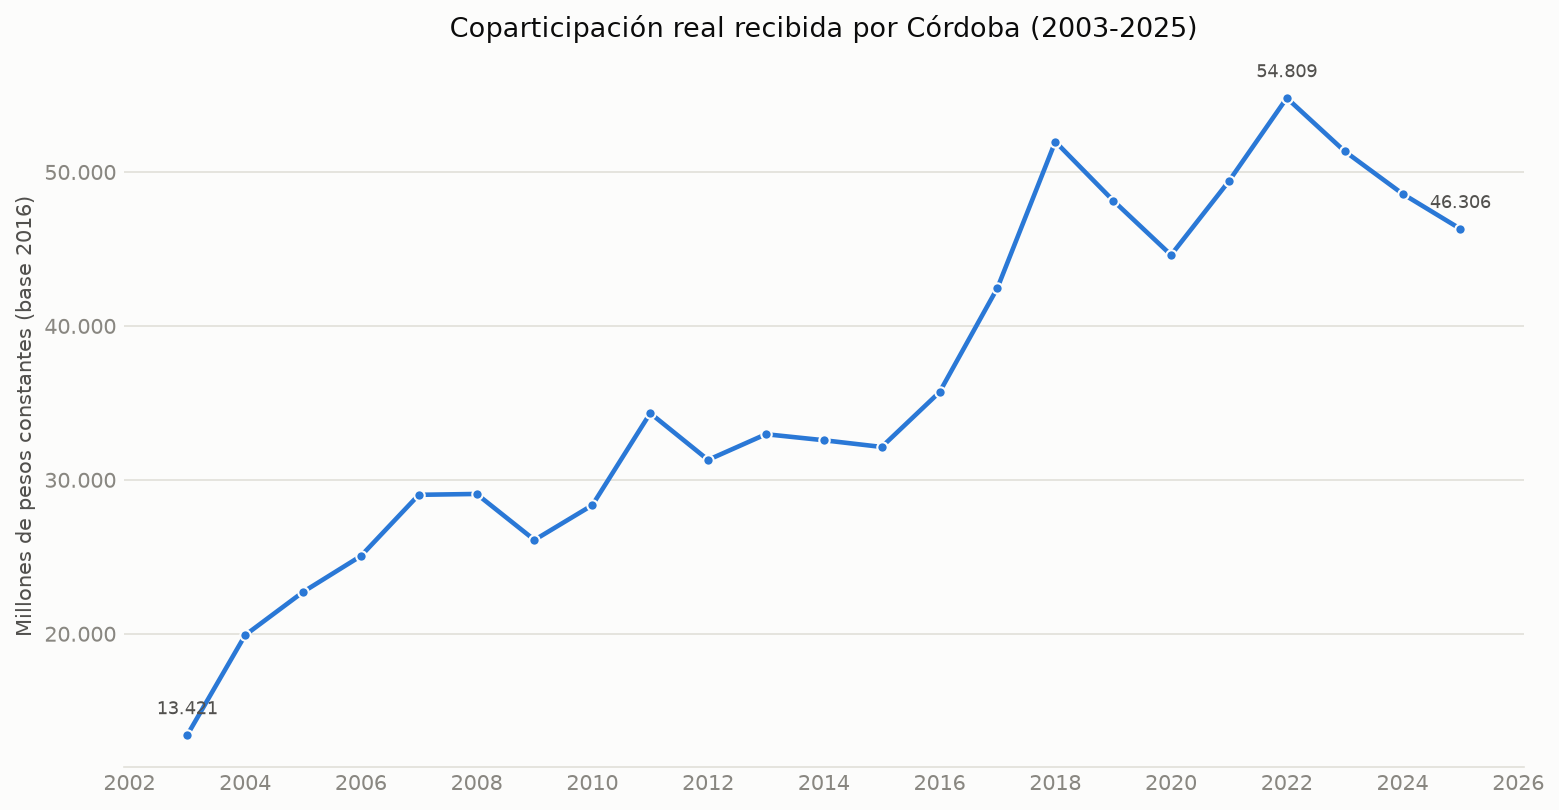

In [3]:
cordoba = df[df["provincia"] == "Córdoba"].sort_values("anio")

fig, ax = plt.subplots(figsize=(10.5, 5.5), dpi=150)
ax.plot(
    cordoba["anio"], cordoba["monto_real_base2016"],
    color=COLOR_CORDOBA, linewidth=2.2, marker="o", markersize=5,
    markerfacecolor=COLOR_CORDOBA, markeredgecolor=SURFACE, markeredgewidth=1,
)

# Etiquetas directas selectivas: primer punto, mínimo, máximo y último punto.
idx_max = cordoba["monto_real_base2016"].idxmax()
idx_min = cordoba["monto_real_base2016"].idxmin()
for idx in sorted(set([cordoba.index[0], idx_min, idx_max, cordoba.index[-1]])):
    row = cordoba.loc[idx]
    ax.annotate(
        f"{row['monto_real_base2016']:,.0f}".replace(",", "."),
        (row["anio"], row["monto_real_base2016"]),
        textcoords="offset points", xytext=(0, 10), ha="center",
        fontsize=8.5, color=INK_SECONDARY,
    )

ax.set_title("Coparticipación real recibida por Córdoba (2003-2025)", fontsize=13, color=INK_PRIMARY, pad=14)
ax.set_ylabel("Millones de pesos constantes (base 2016)", fontsize=10)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)
plt.setp(ax.get_xticklabels(), rotation=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cordoba_evolucion_real_2003_2025.png", dpi=300, facecolor=SURFACE)
plt.show()


**Lectura**: la coparticipación real de Córdoba creció fuerte entre 2003 y 2008
(recuperación pos-crisis 2001-2002), cayó en 2009 (crisis financiera internacional),
se recuperó hasta un primer pico en 2011, cayó en 2012 y luego se mantuvo prácticamente
estancada hasta 2015. A partir de 2016 vuelve a crecer hasta un nuevo pico en 2018, cae
en 2019-2020 (recesión y pandemia), alcanza su punto más alto de toda la serie en 2022,
y vuelve a caer en 2023-2025 — consistente con el contexto de ajuste fiscal de esos años
a nivel nacional. En pesos constantes, 2025 está por encima del nivel de 2003-2007 pero
por debajo de los picos de 2011, 2018 y 2022.


## 3. Comparativo: Córdoba vs. provincias de referencia

Se compara contra Buenos Aires, Santa Fe y Mendoza. **Importante**: esta es una
comparación en niveles absolutos de pesos (no per cápita), así que Buenos Aires —
la provincia más poblada del país — se ve muy por encima solo por su tamaño. Una
comparación per cápita o como porcentaje del gasto provincial queda para los
próximos núcleos de este proyecto.


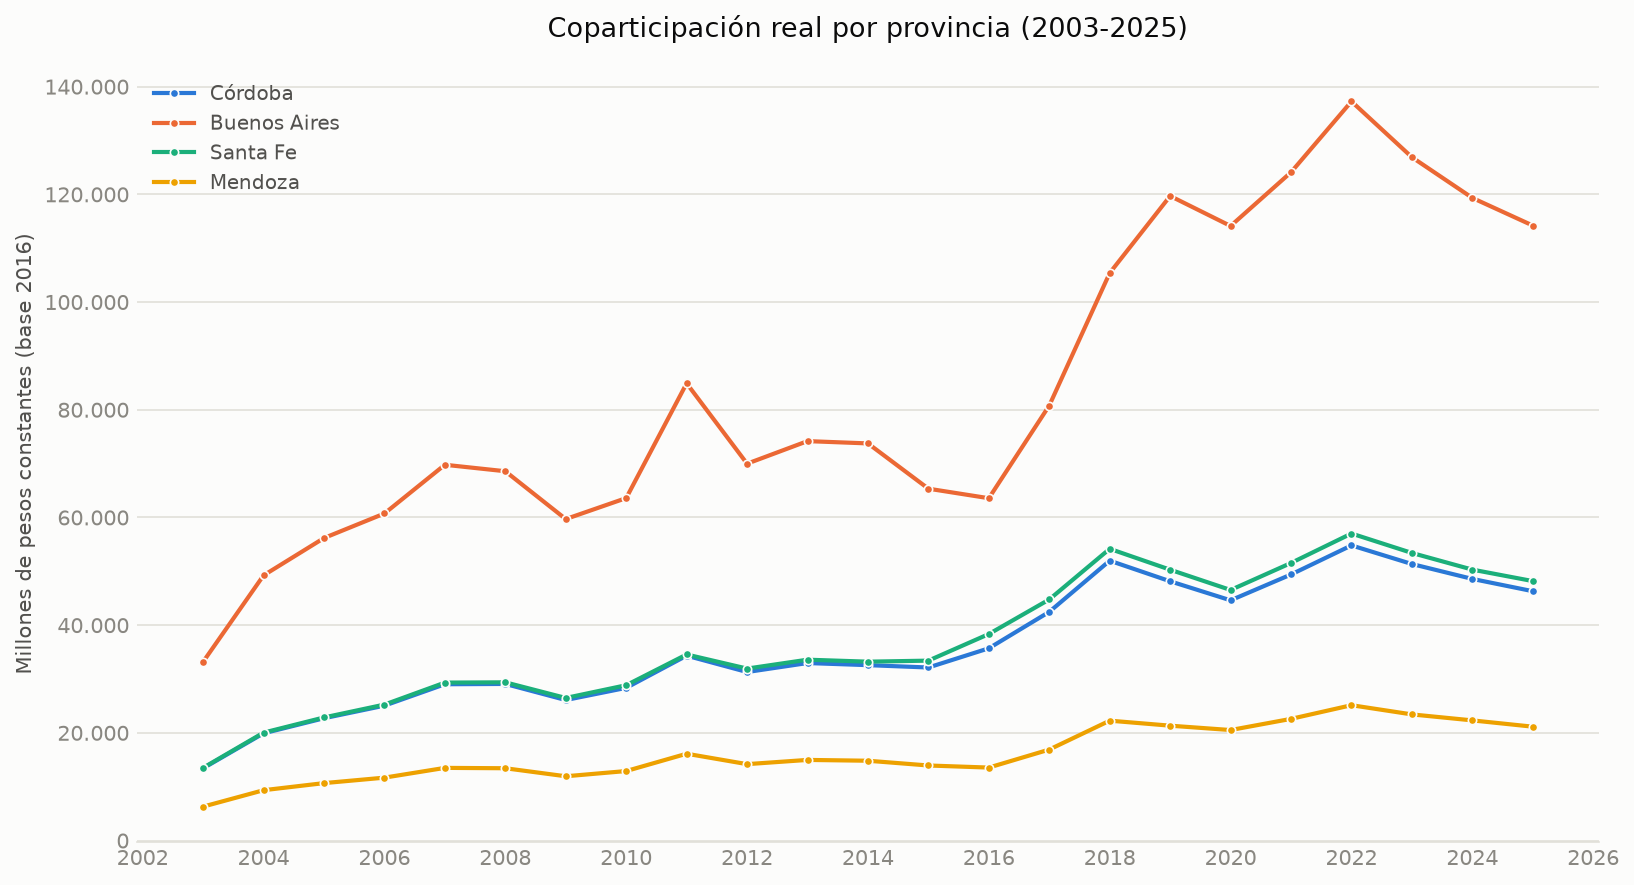

In [4]:
provincias_referencia = ["Córdoba", "Buenos Aires", "Santa Fe", "Mendoza"]
colores = {
    "Córdoba": COLOR_CORDOBA,
    "Buenos Aires": COLOR_BUENOS_AIRES,
    "Santa Fe": COLOR_SANTA_FE,
    "Mendoza": COLOR_MENDOZA,
}

fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
for provincia in provincias_referencia:
    serie = df[df["provincia"] == provincia].sort_values("anio")
    ax.plot(
        serie["anio"], serie["monto_real_base2016"],
        color=colores[provincia], linewidth=2, marker="o", markersize=4,
        markerfacecolor=colores[provincia], markeredgecolor=SURFACE, markeredgewidth=0.8,
        label=provincia,
    )

ax.set_title("Coparticipación real por provincia (2003-2025)", fontsize=13, color=INK_PRIMARY, pad=14)
ax.set_ylabel("Millones de pesos constantes (base 2016)", fontsize=10)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", ".")))
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)
legend = ax.legend(frameon=False, loc="upper left", fontsize=9.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparativo_provincias_real_2003_2025.png", dpi=300, facecolor=SURFACE)
plt.show()


## 4. Comparativo en términos relativos (indexado, 2003 = 100)

El gráfico anterior compara niveles absolutos de pesos, así que Buenos Aires —la
provincia más poblada y con más recursos— domina el gráfico solo por su tamaño, no
porque haya *crecido* más que las demás. Para responder eso, se indexa cada serie a
su propio valor de 2003 (= 100) y se comparan las trayectorias relativas en un solo
eje, sin per cápita (no hay datos de población en este proyecto) pero neutralizando
la diferencia de escala entre provincias.


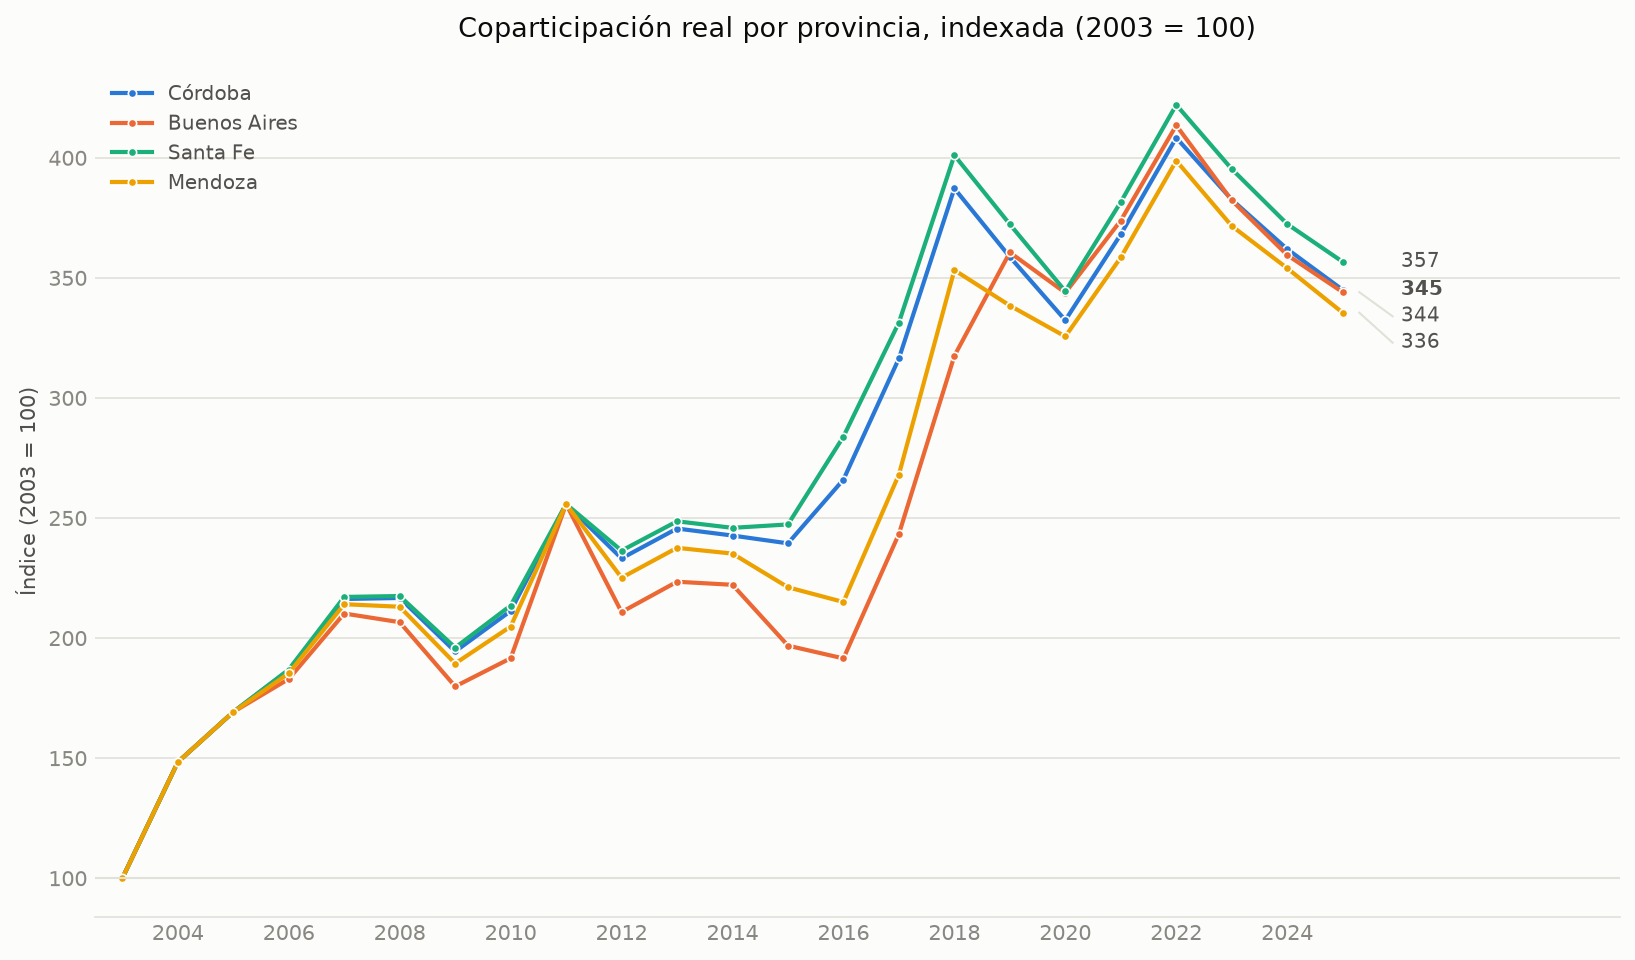

In [5]:
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
indexado_final = {}
for provincia in provincias_referencia:
    serie = df[df["provincia"] == provincia].sort_values("anio").set_index("anio")["monto_real_base2016"]
    base_2003 = serie.loc[2003]
    indexado = serie / base_2003 * 100
    indexado_final[provincia] = indexado.loc[2025]
    ax.plot(
        indexado.index, indexado.values,
        color=colores[provincia], linewidth=2, marker="o", markersize=4,
        markerfacecolor=colores[provincia], markeredgecolor=SURFACE, markeredgewidth=0.8,
        label=provincia,
    )

# Etiquetas directas en el extremo derecho -- como los 4 valores finales quedan muy
# cerca (335-357), se espacian verticalmente para que no se pisen (nunca apilar
# etiquetas encimadas: ver marks-and-anatomy.md), con una línea guía fina hacia el
# punto real cuando el valor se desplazó de su posición natural.
orden = sorted(indexado_final.items(), key=lambda kv: kv[1], reverse=True)
ax.set_xlim(2002.5, 2030)
min_gap = 11  # puntos de índice mínimos entre etiquetas consecutivas
etiquetas_y = []
for _, valor in orden:
    y = valor if not etiquetas_y else min(valor, etiquetas_y[-1] - min_gap)
    etiquetas_y.append(y)

for (provincia, valor_real), y_etiqueta in zip(orden, etiquetas_y):
    if abs(y_etiqueta - valor_real) > 1:
        ax.plot([2025.3, 2025.9], [valor_real, y_etiqueta], color=GRID_COLOR, linewidth=1, zorder=1)
    ax.annotate(
        f"{valor_real:,.0f}",
        (2025.9, y_etiqueta),
        xytext=(4, 0), textcoords="offset points", ha="left", va="center",
        fontsize=9.5, color=INK_SECONDARY, fontweight=("bold" if provincia == "Córdoba" else "normal"),
    )

ax.axhline(100, color=GRID_COLOR, linewidth=1)
ax.set_title("Coparticipación real por provincia, indexada (2003 = 100)", fontsize=13, color=INK_PRIMARY, pad=14)
ax.set_ylabel("Índice (2003 = 100)", fontsize=10)
ax.set_xlabel("")
ax.set_xticks(range(2004, 2026, 2))  # no extender ticks al espacio en blanco reservado para las etiquetas
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)
legend = ax.legend(frameon=False, loc="upper left", fontsize=9.5)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparativo_provincias_indexado_2003_2025.png", dpi=300, facecolor=SURFACE)
plt.show()


**Lectura**: en términos relativos las cuatro provincias son casi indistinguibles —
todas terminan 2025 entre 335 y 357 puntos (multiplicaron su coparticipación real de
2003 entre 3,4 y 3,6 veces), con Santa Fe apenas por encima del resto y Mendoza
apenas por debajo. Córdoba, con 345 puntos, queda justo en el medio del grupo. Esto
confirma con un número lo que el gráfico absoluto sugería: el patrón de la serie
responde a la dinámica agregada del régimen de coparticipación (cuánto crece la masa
total distribuida), no a que a Córdoba (u otra provincia) le vaya sistemáticamente
mejor o peor que al resto dentro del régimen.


## 5. Conclusiones y próximos pasos

- Las cuatro provincias siguen una trayectoria prácticamente idéntica en su forma
  (recuperación 2003-2008, caída en 2009, pico en 2011, estancamiento 2012-2015,
  recuperación 2016-2018, caída 2019-2020, pico en 2022, caída 2023-2025) **y en
  magnitud relativa** (todas entre 335 y 357 puntos indexados a 2003=100 al cierre de
  2025), lo que confirma que el patrón responde a la dinámica agregada del régimen de
  coparticipación (masa total distribuida) más que a factores específicos de cada
  provincia.
- Buenos Aires recibe montos absolutos muy superiores al resto por ser la provincia
  más poblada, pero en términos relativos no se distingue del resto — no es
  comparable en niveles sin ajustar por población o por otra base (eso se aborda en
  el Núcleo 2, "Aporte vs. recibo por provincia").
- **Limitaciones a tener en cuenta** (detalladas en `docs/methodology.md`):
  - El rango 2003-2025 depende, para 2003-2015, de un IPC empalmado a partir de una
    fuente privada (Fundación Norte y Sur / Orlando Ferreres) para el tramo 2007-2015,
    porque el IPC oficial de esos años está ampliamente desacreditado por la
    intervención del INDEC. Esa fuente tiene una limitación propia sin resolver (ver
    "Empalme del IPC 2003-2015" en `docs/methodology.md`): no se pudo verificar el
    contenido exacto de su nota "Ver metodología".
  - No se llega a 1990 porque no hay una fuente de montos nominales de coparticipación
    por provincia anterior a 2003.
  - La definición de "coparticipación" usada excluye otros regímenes de Recursos de
    Origen Nacional (IVA, Ganancias, Bienes Personales, etc.).
